<a href="https://colab.research.google.com/github/jesux009/03MIAR-Algoritmos-de-Optimizaci-n/blob/main/Algoritmos_AG3_(Algoritmos_metaheur%C3%ADsticos).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AG3 - Actividad Guiada 3
Nombre: Raul Reyero <br>
Link:   https://colab.research.google.com/drive/1Q1X9hLb2eoba9MNfSASwsVM53B-PQ7GB?usp=sharing <br>
Github: https://github.com/jesux009/03MIAR-Algoritmos-de-Optimizaci-n
<br>


#Carga de librerias

In [1]:
!pip install requests
!pip install tabulate>=0.9 networkx>=3.0
!pip install tsplib95 --no-deps
!pip install deprecated

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsplib95 0.7.1 requires Deprecated~=1.2.9, but you have deprecated 1.3.1 which is incompatible.
tsplib95 0.7.1 requires networkx~=2.1, but you have networkx 3.6.1 which is incompatible.
tsplib95 0.7.1 requires tabulate~=0.8.7, but you have tabulate 0.9.0 which is incompatible.


In [2]:
!pip install deprecated

#Carga de los datos del problema

In [3]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

('swiss42.tsp', <http.client.HTTPMessage at 0x7a679e4d9160>)

In [4]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())


In [41]:
# Nodos

In [42]:
# Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp


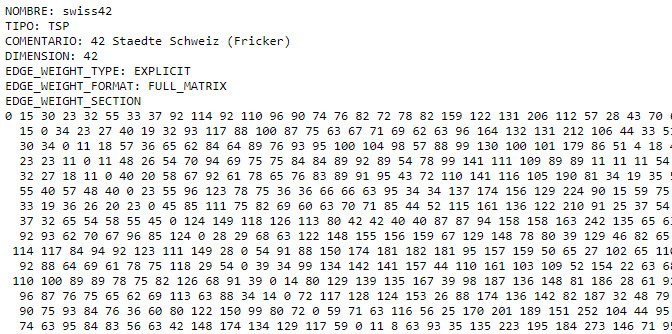

In [7]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

#Funcionas basicas


In [8]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 16, 1, 21, 15, 28, 4, 30, 13, 34, 12, 29, 37, 8, 9, 24, 32, 33, 23, 6, 25, 26, 20, 18, 41, 17, 27, 3, 31, 2, 22, 5, 38, 35, 7, 10, 11, 39, 36, 40, 19, 14]
5273


#BUSQUEDA ALEATORIA

In [27]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 5000)

Mejor solución: [0, 3, 1, 41, 15, 22, 24, 10, 26, 2, 35, 31, 7, 29, 21, 39, 13, 19, 16, 8, 23, 40, 9, 36, 5, 18, 11, 12, 6, 27, 37, 30, 14, 32, 4, 25, 28, 17, 38, 34, 20, 33]
Distancia     : 3793


#BUSQUEDA LOCAL

In [10]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3592
Distancia Mejor Solucion Local: 3320


In [28]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem, printing=True):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      if printing:
        print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
        print("Distancia      :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  27 , la mejor solución encontrada es: [0, 5, 13, 26, 18, 4, 30, 29, 39, 21, 24, 40, 23, 41, 25, 11, 12, 10, 8, 9, 22, 38, 34, 33, 20, 35, 36, 37, 15, 16, 14, 19, 7, 17, 31, 32, 28, 2, 27, 3, 6, 1]
Distancia      : 1569


#SIMULATED ANNEALING


In [39]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

In [40]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 28, 30, 32, 34, 38, 22, 8, 3, 1, 31, 20, 6, 18, 12, 11, 2, 27, 29, 39, 21, 24, 40, 23, 9, 26, 13, 19, 16, 15, 37, 17, 36, 35, 33, 7, 14, 5, 25, 41, 10, 4]
con una distancia total de 2168


## Mejora de la solución inicial

In [31]:
# Implementamos un generador de solución inicial voraz-aleatorio (que luego se usará para GRASP)

def lista_restringida_candidatos(actual, no_visitados, problem, alpha):
  """
  Genera la Lista Restringida de Candidatos (LRC) para el nodo actual.
  La LRC introduce el equilibrio entre:
    - Voracidad: prioriza nodos cercanos (menor coste).
    - Aleatoriedad: no obliga a elegir siempre el mejor.
  El parámetro alpha (entre 0 y 1) controla ese equilibrio. Cuanto más alto sea, habrá mayor influencia de la aleatoriedad y menor voracidad.
  """
  # Calculamos el coste (distancia) desde el nodo actual a cada candidato
  costes = []
  for nodo in no_visitados:
      d = distancia(actual, nodo, problem)
      costes.append((nodo, d))
  # Ordenamos candidatos por distancia creciente (criterio voraz)
  costes.sort(key=lambda x: x[1])
  # Identificamos el mejor y peor coste dentro de los candidatos
  min_coste = costes[0][1]
  max_coste = costes[-1][1]
  # Definimos el umbral de entrada a la LRC según GRASP clásico
  # Solo entrarán candidatos cuyo coste esté suficientemente cerca del mejor
  # Alternativamente podría definirse por los k mejores nodos
  umbral = min_coste + alpha * (max_coste - min_coste)
  # Construimos la Lista Restringida de Candidatos
  LRC = [nodo for nodo, coste in costes if coste <= umbral]
  return LRC


def construir_solucion_voraz(problem, alpha):
  """
  Fase de construcción de GRASP: genera una solución inicial mediante un procedimiento voraz aleatorizado adaptativo.
  """
  Nodos = list(problem.get_nodes())
  # Empezamos en el nodo 0
  solucion = [Nodos[0]]
  # Definimos el conjunto de nodos aún no visitados
  no_visitados = set(Nodos[1:])
  # Construcción incremental de la ruta
  while no_visitados:
    # Partimos del último nodo de la solución parcial
    actual = solucion[-1]
    # Generamos la LRC
    RCL = lista_restringida_candidatos(actual, no_visitados, problem, alpha)
    # Seleccionamos aleatoriamente uno de los mejores candidatos
    siguiente = random.choice(RCL)
    # Añadimos el nodo a la solución y lo eliminamos de la lista de no visitados
    solucion.append(siguiente)
    no_visitados.remove(siguiente)
  return solucion

In [38]:
def recocido_simulado_mejorado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = construir_solucion_voraz(problem, alpha=0.5)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 27, 2, 4, 3, 32, 20, 36, 35, 17, 31, 37, 16, 19, 13, 18, 39, 21, 24, 40, 23, 29, 22, 38, 34, 33, 30, 28, 1, 7, 15, 14, 5, 26, 10, 8, 9, 41, 25, 11, 12, 6]
con una distancia total de 1885


#Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [14]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


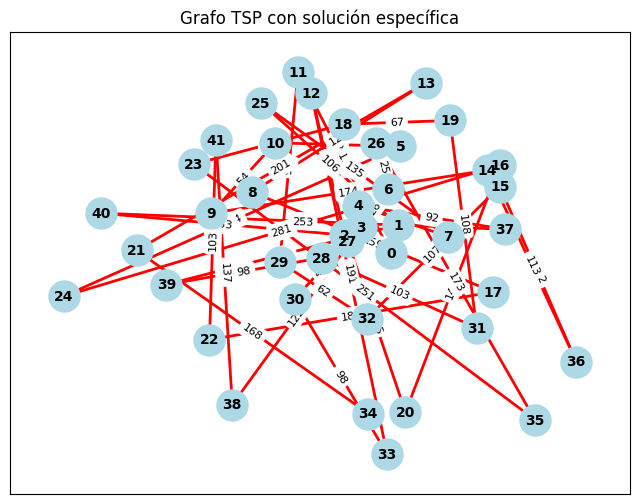

In [15]:
plot_tsp_solution(problem.edge_weights, crear_solucion(Nodos))

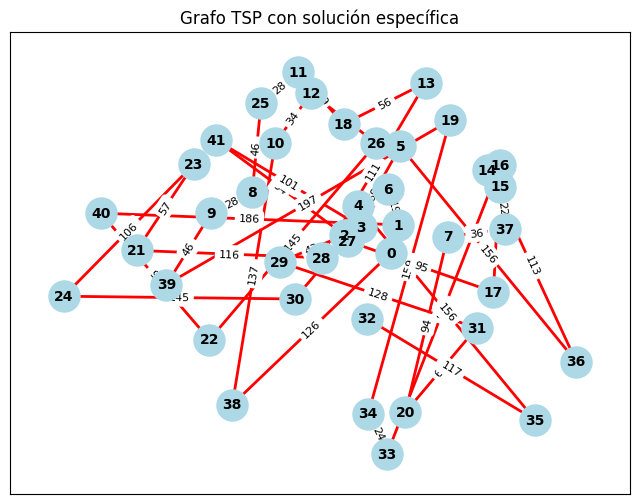

In [16]:
plot_tsp_solution(problem.edge_weights, solucion)

# GRASP

In [25]:
###############################################################################
# CONSTRUCCIÓN GRASP
###############################################################################

def lista_restringida_candidatos(actual, no_visitados, problem, alpha):
  """
  Genera la Lista Restringida de Candidatos (LRC) para el nodo actual.
  La LRC introduce el equilibrio entre:
    - Voracidad: prioriza nodos cercanos (menor coste).
    - Aleatoriedad: no obliga a elegir siempre el mejor.
  El parámetro alpha (entre 0 y 1) controla ese equilibrio. Cuanto más alto sea, habrá mayor influencia de la aleatoriedad y menor voracidad.
  """
  # Calculamos el coste (distancia) desde el nodo actual a cada candidato
  costes = []
  for nodo in no_visitados:
      d = distancia(actual, nodo, problem)
      costes.append((nodo, d))
  # Ordenamos candidatos por distancia creciente (criterio voraz)
  costes.sort(key=lambda x: x[1])
  # Identificamos el mejor y peor coste dentro de los candidatos
  min_coste = costes[0][1]
  max_coste = costes[-1][1]
  # Definimos el umbral de entrada a la LRC según GRASP clásico
  # Solo entrarán candidatos cuyo coste esté suficientemente cerca del mejor
  # Alternativamente podría definirse por los k mejores nodos
  umbral = min_coste + alpha * (max_coste - min_coste)
  # Construimos la Lista Restringida de Candidatos
  LRC = [nodo for nodo, coste in costes if coste <= umbral]
  return LRC


def construir_solucion_voraz(problem, alpha):
  """
  Fase de construcción de GRASP: genera una solución inicial mediante un procedimiento voraz aleatorizado adaptativo.
  """
  Nodos = list(problem.get_nodes())
  # Empezamos en el nodo 0
  solucion = [Nodos[0]]
  # Definimos el conjunto de nodos aún no visitados
  no_visitados = set(Nodos[1:])
  # Construcción incremental de la ruta
  while no_visitados:
    # Partimos del último nodo de la solución parcial
    actual = solucion[-1]
    # Generamos la LRC
    RCL = lista_restringida_candidatos(actual, no_visitados, problem, alpha)
    # Seleccionamos aleatoriamente uno de los mejores candidatos
    siguiente = random.choice(RCL)
    # Añadimos el nodo a la solución y lo eliminamos de la lista de no visitados
    solucion.append(siguiente)
    no_visitados.remove(siguiente)
  return solucion


def grasp(problem, iteraciones, alpha=0.3):
  """
  Implementación del algoritmo GRASP completo para el TSP. Contiene dos fases:
    1. Construcción voraz aleatorizada de una solución inicial.
    2. Mejora mediante búsqueda local (2-opt en nuestra práctica).
  El proceso se repite un número de iteraciones determinado, almacenando siempre la mejor solución global encontrada.

  Argumentos:
    - problem: Instancia de TSPLIB.
    - iteraciones (int): Número de soluciones GRASP generadas.
    - alpha (float): Nivel de aleatoriedad en la construcción.

  Retornos:
    - Mejor tour encontrado.
    - Distancia total asociada.
  """

  mejor_solucion = []
  mejor_distancia = float('inf')
  for i in range(iteraciones):
    # 1. Construcción voraz aleatorizada
    solucion = construir_solucion_voraz(problem, alpha)
    # 2. Mejora de la solución por búsqueda local
    solucion = busqueda_local(solucion, problem, printing=False)
    # 3. Evaluación
    d = distancia_total(solucion, problem)
    # 4. Actualización mejor global
    if d < mejor_distancia:
      mejor_solucion = solucion
      mejor_distancia = d
  return mejor_solucion, mejor_distancia

solucion_GRASP, distancia_GRASP = grasp(problem, iteraciones=20, alpha=0.3)
print(f'Solución GRASP : {solucion_GRASP}')
print(f'Distancia GRASP: {distancia_GRASP}')


Solución GRASP : [0, 6, 26, 5, 13, 19, 14, 16, 15, 37, 7, 17, 31, 36, 35, 20, 33, 34, 32, 28, 27, 2, 3, 4, 18, 12, 11, 25, 10, 41, 23, 29, 30, 38, 22, 39, 24, 40, 21, 9, 8, 1]
Distancia GRASP: 1431
